# S4/S5 · AndinaLog · Notebook 3 · Interpretación de pedidos WMS

Este notebook **solo lee** `andinalog_wms_orders_silver.csv`, generado por el notebook 2. Calcula estadísticas de pedidos, entregas y OTIF, muestra gráficos y redacta una síntesis descriptiva automática. No corrige datos, no modifica Silver, no cruza otros CSV y no exporta archivos.

**Alcance:** los resultados describen exclusivamente los pedidos utilizables. Las filas en cuarentena no se incorporan a los indicadores. Las diferencias entre centros o plazos prometidos no demuestran por sí solas diferencias de desempeño ni causas operativas: pueden reflejar composición de pedidos, rutas y condiciones que este archivo no documenta.


## 1 · Carga local o desde Drive

En local, ejecuta el notebook desde cualquier carpeta dentro del repositorio. En Colab, ajusta `RUTA_PROYECTO_DRIVE` a la carpeta que contiene `S4/`.


In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ENTORNO = "auto"  # "auto", "local" o "drive"
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
NOMBRE_SILVER = "andinalog_wms_orders_silver.csv"
COLUMNAS_SILVER = [
    "order_id", "cliente_id", "producto_id", "fecha_despacho", "centro_distribucion",
    "camion_id", "chofer_id", "cantidad_solicitada", "cantidad_entregada",
    "tiempo_entrega_prometido_hrs", "tiempo_entrega_real_hrs",
    "otif_on_time", "otif_in_full", "otif",
]
COLUMNAS_NUMERICAS = [
    "cantidad_solicitada", "cantidad_entregada", "tiempo_entrega_prometido_hrs",
    "tiempo_entrega_real_hrs", "otif_on_time", "otif_in_full", "otif",
]

def encontrar_raiz_local():
    for carpeta in [Path.cwd(), *Path.cwd().parents]:
        if (carpeta / "S4" / "andinalog_wms_orders" / "notebook2" / "salidas" / NOMBRE_SILVER).is_file():
            return carpeta
    raise FileNotFoundError("No se encontró Silver. Ejecuta dentro del proyecto después del notebook 2.")

def obtener_ruta_silver():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        raiz = Path(RUTA_PROYECTO_DRIVE)
    elif entorno == "local":
        raiz = encontrar_raiz_local()
    else:
        raise ValueError("ENTORNO debe ser 'auto', 'local' o 'drive'")
    ruta = raiz / "S4" / "andinalog_wms_orders" / "notebook2" / "salidas" / NOMBRE_SILVER
    if not ruta.is_file():
        raise FileNotFoundError(f"No se encontró Silver: {ruta}")
    return ruta

RUTA_SILVER = obtener_ruta_silver()
print("Silver:", RUTA_SILVER)


Silver: c:\Users\remrodri\Github\practicasNotebookColab\S4\andinalog_wms_orders\notebook2\salidas\andinalog_wms_orders_silver.csv


## 2 · Contrato de entrada

Las conversiones numéricas y de fecha se usan solo en memoria para el análisis. Si Silver contiene datos inesperados, el notebook se detiene: no corrige pedidos ni redefine OTIF.


In [3]:
df_silver_raw = pd.read_csv(RUTA_SILVER, dtype="string", encoding="utf-8-sig", keep_default_na=False)
if list(df_silver_raw.columns) != COLUMNAS_SILVER:
    raise ValueError(f"Esquema Silver inesperado: {list(df_silver_raw.columns)}")
if df_silver_raw.empty:
    raise ValueError("Silver está vacío")
if df_silver_raw[COLUMNAS_SILVER].eq("").any().any():
    raise ValueError("Silver contiene valores vacíos")
if df_silver_raw["order_id"].duplicated().any():
    raise ValueError("Silver contiene pedidos duplicados")

df = df_silver_raw.copy(deep=True)
df["fecha_despacho"] = pd.to_datetime(df["fecha_despacho"], format="%Y-%m-%d %H:%M:%S", errors="raise")
for columna in COLUMNAS_NUMERICAS:
    df[columna] = pd.to_numeric(df[columna], errors="raise")
if df[COLUMNAS_NUMERICAS].isna().any().any():
    raise ValueError("Silver contiene valores numéricos faltantes")
if df["cantidad_solicitada"].le(0).any() or df["cantidad_entregada"].lt(0).any() or df["cantidad_entregada"].gt(df["cantidad_solicitada"]).any():
    raise ValueError("Silver contiene cantidades incompatibles")
if df["tiempo_entrega_prometido_hrs"].le(0).any() or df["tiempo_entrega_real_hrs"].lt(0).any():
    raise ValueError("Silver contiene tiempos incompatibles")
for columna in ["otif_on_time", "otif_in_full", "otif"]:
    if not df[columna].isin([0, 1]).all():
        raise ValueError(f"Silver contiene una bandera inválida en {columna}")
if not df["otif_on_time"].eq(df["tiempo_entrega_real_hrs"].le(df["tiempo_entrega_prometido_hrs"]).astype(int)).all():
    raise ValueError("La bandera on_time no coincide con los tiempos")
if not df["otif_in_full"].eq(df["cantidad_entregada"].ge(df["cantidad_solicitada"]).astype(int)).all():
    raise ValueError("La bandera in_full no coincide con las cantidades")
if not df["otif"].eq(df["otif_on_time"] * df["otif_in_full"]).all():
    raise ValueError("OTIF no coincide con on_time e in_full")

df["fecha_registrada"] = df["fecha_despacho"].dt.date
df["diferencia_entrega_hrs"] = df["tiempo_entrega_real_hrs"] - df["tiempo_entrega_prometido_hrs"]
print(f"Pedidos utilizables: {len(df):,}")
print(f"Centros: {df['centro_distribucion'].nunique()}; fechas de despacho: {df['fecha_registrada'].nunique()}")
print("Periodo de despacho:", df["fecha_despacho"].min(), "a", df["fecha_despacho"].max())


Pedidos utilizables: 7,279
Centros: 5; fechas de despacho: 30
Periodo de despacho: 2026-08-01 00:07:00 a 2026-08-30 23:58:00


## 3 · Indicadores generales

OTIF es la proporción de pedidos con `otif=1`. Puntualidad y entrega completa se informan por separado. El **porcentaje de unidades entregadas** divide las unidades entregadas totales entre las solicitadas totales; no equivale al porcentaje de pedidos completos.


In [4]:
def construir_resumen_general(datos):
    n = len(datos)
    indicadores = [
        ("Pedidos OTIF", int(datos["otif"].sum()), n),
        ("Pedidos puntuales", int(datos["otif_on_time"].sum()), n),
        ("Pedidos completos", int(datos["otif_in_full"].sum()), n),
        ("Unidades entregadas", float(datos["cantidad_entregada"].sum()), float(datos["cantidad_solicitada"].sum())),
    ]
    return pd.DataFrame([
        {"indicador": nombre, "numerador": num, "denominador": den, "porcentaje": 100*num/den}
        for nombre, num, den in indicadores
    ])

resumen_general = construir_resumen_general(df)
display(resumen_general.round(2))

resumen_tiempos = df[["tiempo_entrega_prometido_hrs", "tiempo_entrega_real_hrs", "diferencia_entrega_hrs"]].describe(percentiles=[0.25, 0.5, 0.75]).T
resumen_tiempos = resumen_tiempos.rename(columns={"count":"pedidos","mean":"media","std":"desv_est","min":"minimo","25%":"p25","50%":"mediana","75%":"p75","max":"maximo"})
display(resumen_tiempos[["pedidos","media","mediana","desv_est","minimo","p25","p75","maximo"]].round(2))


,indicador,numerador,denominador,porcentaje
0,Pedidos OTIF,5776.0,7279.0,79.35
1,Pedidos puntuales,6217.0,7279.0,85.41
2,Pedidos completos,6763.0,7279.0,92.91
3,Unidades entregadas,1829719.0,1835142.0,99.70


,pedidos,media,mediana,desv_est,minimo,p25,p75,maximo
tiempo_entrega_prometido_hrs,7279.0,45.24,48.0,18.36,24.0,24.0,48.0,72.0
tiempo_entrega_real_hrs,7279.0,37.57,36.7,17.24,8.4,21.7,48.9,95.3
diferencia_entrega_hrs,7279.0,-7.67,-6.5,8.36,-46.8,-12.1,-2.2,23.3


## 4 · Comparación entre centros

La tabla muestra `n` y el numerador de cada tasa. Los centros tienen cantidades distintas de pedidos; comparar solo el número absoluto de incumplimientos sería engañoso. Se evita atribuir diferencias a personal o camiones concretos.


In [5]:
def resumir_centros(datos):
    tabla = datos.groupby("centro_distribucion", sort=True).agg(
        pedidos=("order_id", "size"),
        pedidos_otif=("otif", "sum"),
        pedidos_puntuales=("otif_on_time", "sum"),
        pedidos_completos=("otif_in_full", "sum"),
        unidades_solicitadas=("cantidad_solicitada", "sum"),
        unidades_entregadas=("cantidad_entregada", "sum"),
        diferencia_entrega_mediana_hrs=("diferencia_entrega_hrs", "median"),
    )
    tabla["pct_otif"] = 100*tabla["pedidos_otif"]/tabla["pedidos"]
    tabla["pct_puntuales"] = 100*tabla["pedidos_puntuales"]/tabla["pedidos"]
    tabla["pct_completos"] = 100*tabla["pedidos_completos"]/tabla["pedidos"]
    tabla["pct_unidades_entregadas"] = 100*tabla["unidades_entregadas"]/tabla["unidades_solicitadas"]
    tabla["otif_n_de_N"] = [f"{int(a)}/{int(b)}" for a,b in zip(tabla["pedidos_otif"], tabla["pedidos"])]
    return tabla.sort_values("pedidos", ascending=False)

tabla_centros = resumir_centros(df)
assert tabla_centros["pedidos"].sum() == len(df)
display(tabla_centros.round(2))


,pedidos,pedidos_otif,pedidos_puntuales,pedidos_completos,unidades_solicitadas,unidades_entregadas,diferencia_entrega_mediana_hrs,pct_otif,pct_puntuales,pct_completos,pct_unidades_entregadas,otif_n_de_N
centro_distribucion,,,,,,,,,,,,
Cochabamba,1498,1194,1291,1387,382198,381037.0,-6.7,79.71,86.18,92.59,99.7,1194/1498
La Paz,1498,1162,1258,1392,376176,374974.0,-6.3,77.57,83.98,92.92,99.68,1162/1498
Oruro,1477,1175,1262,1370,367576,366522.0,-6.4,79.55,85.44,92.76,99.71,1175/1477
Tarija,1437,1136,1223,1334,367070,365969.0,-6.5,79.05,85.11,92.83,99.7,1136/1437
Santa Cruz,1369,1109,1183,1280,342122,341217.0,-6.6,81.01,86.41,93.5,99.74,1109/1369


## 5 · Comparación por plazo prometido

Los grupos de 24, 48 y 72 horas describen el plazo registrado en Silver. Una diferencia de tasa entre grupos no demuestra que cambiar el plazo mejoraría OTIF; los tipos de pedido y las rutas pueden ser distintos.


In [6]:
tabla_plazos = df.groupby("tiempo_entrega_prometido_hrs", sort=True).agg(
    pedidos=("order_id", "size"),
    pedidos_otif=("otif", "sum"),
    pedidos_puntuales=("otif_on_time", "sum"),
    pedidos_completos=("otif_in_full", "sum"),
)
for indicador,columna in [("pct_otif","pedidos_otif"),("pct_puntuales","pedidos_puntuales"),("pct_completos","pedidos_completos")]:
    tabla_plazos[indicador] = 100*tabla_plazos[columna]/tabla_plazos["pedidos"]
assert tabla_plazos["pedidos"].sum() == len(df)
display(tabla_plazos.round(2))


,pedidos,pedidos_otif,pedidos_puntuales,pedidos_completos,pct_otif,pct_puntuales,pct_completos
tiempo_entrega_prometido_hrs,,,,,,,
24,2596,2061,2226,2394,79.39,85.75,92.22
48,2924,2322,2502,2719,79.41,85.57,92.99
72,1759,1393,1489,1650,79.19,84.65,93.8


## 6 · Evolución por fecha de despacho

La fecha disponible es **fecha de despacho**, no fecha real de entrega. El porcentaje diario de OTIF clasifica los pedidos por el día en que salieron. El número de pedidos se muestra como denominador; el gráfico no representa el momento en que se completó la entrega.


In [7]:
tabla_diaria = df.groupby("fecha_registrada", sort=True).agg(
    pedidos=("order_id", "size"),
    pedidos_otif=("otif", "sum"),
    pedidos_puntuales=("otif_on_time", "sum"),
    pedidos_completos=("otif_in_full", "sum"),
)
tabla_diaria["pct_otif"] = 100*tabla_diaria["pedidos_otif"]/tabla_diaria["pedidos"]
assert tabla_diaria["pedidos"].sum() == len(df)
display(tabla_diaria.round(2))


,pedidos,pedidos_otif,pedidos_puntuales,pedidos_completos,pct_otif
fecha_registrada,,,,,
2026-08-01,221,185,195,209,83.71
2026-08-02,229,182,200,210,79.48
2026-08-03,256,219,228,247,85.55
2026-08-04,229,191,203,216,83.41
2026-08-05,254,197,216,234,77.56
2026-08-06,230,180,195,214,78.26
2026-08-07,237,192,205,222,81.01
2026-08-08,239,184,202,216,76.99
2026-08-09,248,201,216,232,81.05


## 7 · Gráficos

Cada tasa aparece con su tamaño de grupo. Los gráficos son descriptivos: no comparan rutas ni ajustan por complejidad del pedido.


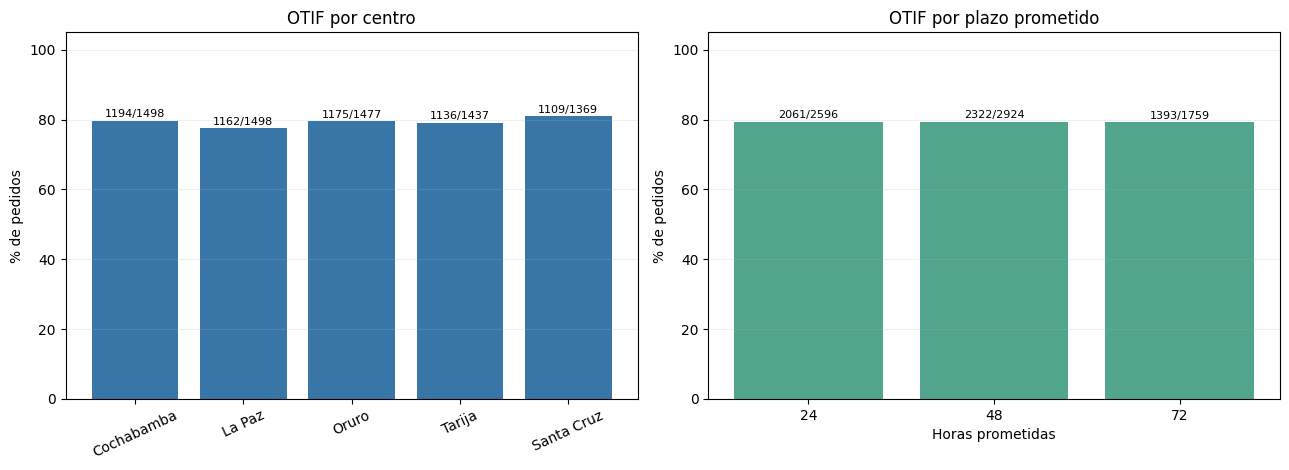

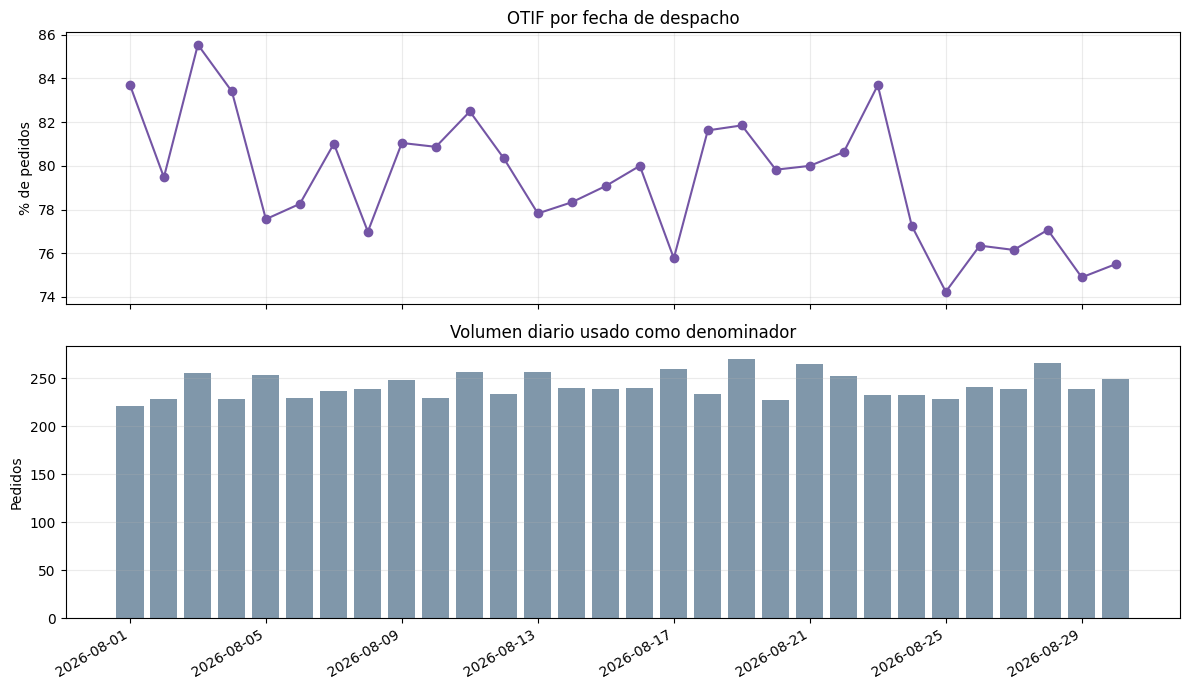

In [8]:
orden = tabla_centros.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
barras = axes[0].bar(orden, tabla_centros.loc[orden,"pct_otif"], color="#3976A8")
for barra, centro in zip(barras, orden):
    fila = tabla_centros.loc[centro]
    axes[0].text(barra.get_x()+barra.get_width()/2, barra.get_height()+1,
                 f"{int(fila['pedidos_otif'])}/{int(fila['pedidos'])}", ha="center", fontsize=8)
axes[0].set(title="OTIF por centro", ylabel="% de pedidos")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=25)

plazos = tabla_plazos.index.tolist()
barras = axes[1].bar([str(int(x)) for x in plazos], tabla_plazos.loc[plazos,"pct_otif"], color="#50A58C")
for barra, plazo in zip(barras, plazos):
    fila = tabla_plazos.loc[plazo]
    axes[1].text(barra.get_x()+barra.get_width()/2, barra.get_height()+1,
                 f"{int(fila['pedidos_otif'])}/{int(fila['pedidos'])}", ha="center", fontsize=8)
axes[1].set(title="OTIF por plazo prometido", xlabel="Horas prometidas", ylabel="% de pedidos")
axes[1].set_ylim(0, 105)
for ax in axes: ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
dias = pd.to_datetime(tabla_diaria.index)
axes[0].plot(dias, tabla_diaria["pct_otif"], marker="o", color="#7455A5")
axes[0].set(title="OTIF por fecha de despacho", ylabel="% de pedidos")
axes[0].grid(alpha=0.25)
axes[1].bar(dias, tabla_diaria["pedidos"], color="#8097AA", width=0.8)
axes[1].set(title="Volumen diario usado como denominador", ylabel="Pedidos")
axes[1].grid(axis="y", alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 8 · Síntesis descriptiva automática

Este texto se calcula con el Silver de la ejecución. Resume observaciones; no explica sus causas.


In [9]:
def redactar_sintesis(datos, centros, plazos, diaria):
    n = len(datos)
    otif = int(datos["otif"].sum())
    puntual = int(datos["otif_on_time"].sum())
    completo = int(datos["otif_in_full"].sum())
    centro_max = centros["pct_otif"].idxmax()
    centro_min = centros["pct_otif"].idxmin()
    dia_max = diaria["pct_otif"].idxmax()
    dia = diaria.loc[dia_max]
    texto = [
        f"ALCANCE: {n:,} pedidos utilizables de {len(centros)} centros. "
        "Las filas en cuarentena no forman parte de estos cálculos.",
        f"RESULTADO GENERAL: OTIF en {otif:,} de {n:,} pedidos ({100*otif/n:.2f} %); "
        f"puntualidad en {puntual:,}/{n:,} ({100*puntual/n:.2f} %) y entrega completa "
        f"en {completo:,}/{n:,} ({100*completo/n:.2f} %).",
        f"CENTROS: el mayor porcentaje OTIF observado corresponde a {centro_max}: "
        f"{int(centros.loc[centro_max,'pedidos_otif'])}/{int(centros.loc[centro_max,'pedidos'])} "
        f"({centros.loc[centro_max,'pct_otif']:.2f} %). El menor corresponde a {centro_min}: "
        f"{int(centros.loc[centro_min,'pedidos_otif'])}/{int(centros.loc[centro_min,'pedidos'])} "
        f"({centros.loc[centro_min,'pct_otif']:.2f} %).",
        f"PLAZOS: se observan {len(plazos)} grupos de horas prometidas. La tabla muestra "
        "las tasas y el número de pedidos de cada grupo; esas diferencias no prueban "
        "el efecto de cambiar un plazo.",
        f"FECHA A REVISAR: {dia_max} tiene el mayor porcentaje OTIF diario observado: "
        f"{int(dia['pedidos_otif'])}/{int(dia['pedidos'])} ({dia['pct_otif']:.2f} %). "
        "Corresponde a la fecha de despacho, no a la de entrega.",
        "LÍMITE: el dataset no aporta ruta, distancia, requisitos específicos de producto, condiciones "
        "operativas ni causas de incumplimiento. No se atribuyen diferencias a un centro, "
        "conductor o camión de forma causal.",
    ]
    return "\n\n".join(texto)

sintesis_descriptiva = redactar_sintesis(df, tabla_centros, tabla_plazos, tabla_diaria)
print(sintesis_descriptiva)


ALCANCE: 7,279 pedidos utilizables de 5 centros. Las filas en cuarentena no forman parte de estos cálculos.

RESULTADO GENERAL: OTIF en 5,776 de 7,279 pedidos (79.35 %); puntualidad en 6,217/7,279 (85.41 %) y entrega completa en 6,763/7,279 (92.91 %).

CENTROS: el mayor porcentaje OTIF observado corresponde a Santa Cruz: 1109/1369 (81.01 %). El menor corresponde a La Paz: 1162/1498 (77.57 %).

PLAZOS: se observan 3 grupos de horas prometidas. La tabla muestra las tasas y el número de pedidos de cada grupo; esas diferencias no prueban el efecto de cambiar un plazo.

FECHA A REVISAR: 2026-08-03 tiene el mayor porcentaje OTIF diario observado: 219/256 (85.55 %). Corresponde a la fecha de despacho, no a la de entrega.

LÍMITE: el dataset no aporta ruta, distancia, requisitos específicos de producto, condiciones operativas ni causas de incumplimiento. No se atribuyen diferencias a un centro, conductor o camión de forma causal.


## 9 · Guía de interpretación

Después de ejecutar, redacta tres hallazgos. Para cada uno anota: **qué se observa**, **qué cifra o gráfico lo respalda**, **qué decisión podría orientar** y **qué no se puede concluir todavía**.

1. ¿Cómo se diferencian OTIF, puntualidad y entrega completa? ¿Cuál de los dos componentes limita más OTIF en estos datos?
2. ¿Qué centro tiene mayor y menor porcentaje observado? Cita pedidos OTIF y pedidos totales; no conviertas una diferencia descriptiva en una evaluación causal.
3. ¿Cambian las tasas entre plazos prometidos? ¿Qué información faltaría para interpretar esa diferencia?
4. ¿Qué fecha de despacho merece revisión y cuántos pedidos la sustentan?

**Limitaciones:** solo pedidos utilizables, un periodo de despacho, sin rutas, distancias, motivos de retraso ni fechas de entrega. Este notebook no lee cuarentena ni estima su efecto por centro. Tampoco une clientes, productos, flota o conductores: esas referencias requieren validación por separado.


## 10 · Validaciones finales

Las tablas deben reconciliar con el Silver. El notebook no escribe ni reemplaza archivos.


In [10]:
assert len(df) == len(df_silver_raw)
assert df["order_id"].is_unique
assert tabla_centros["pedidos"].sum() == len(df)
assert tabla_plazos["pedidos"].sum() == len(df)
assert tabla_diaria["pedidos"].sum() == len(df)
assert tabla_centros["pedidos_otif"].sum() == int(df["otif"].sum())
assert tabla_plazos["pedidos_otif"].sum() == int(df["otif"].sum())
assert tabla_diaria["pedidos_otif"].sum() == int(df["otif"].sum())
assert f"{len(df):,} pedidos utilizables" in sintesis_descriptiva
print("Validaciones correctas. Silver no fue modificado.")


Validaciones correctas. Silver no fue modificado.
